In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import math
from itertools import permutations

import geopandas as gpd
from shapely.geometry import box

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib import colors
from matplotlib import gridspec
import matplotlib.patheffects as pe
from matplotlib.colors import Normalize, TwoSlopeNorm
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import seaborn as sns

from adjustText import adjust_text

In [2]:
ds = xr.open_dataset("/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess/bootstrap_summary.nc",
                    engine='h5netcdf')
# Generator site list
gen_csv = pd.read_csv("/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess/gen_info.csv")

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: /home/129/ms5578/ms5578_plotting/bin/python3 -m pip install --upgrade pip


In [3]:
hw_dates = pd.read_csv("/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess/alpine_cluster.csv")
cluster = hw_dates.columns.tolist()
cluster.pop(0)

cluster = gen_csv[gen_csv['DUID'].isin(cluster)][['DUID','lat','lon']]

In [4]:
output_dir = '/g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/hw/C2/bootstrap'

In [5]:
lon = ds.coords['lon'].values
lat = ds.coords['lat'].values

extent = [ds.coords['lon'].min().item(),
          ds.coords['lon'].max().item(),
          ds.coords['lat'].min().item(),
          ds.coords['lat'].max().item()]
lon_min, lon_max, lat_min, lat_max = extent

In [6]:
# Load shapefile
gdf = gpd.read_file('/g/data/ng72/ms5578/ID_HW_BARRA/data/raw/contours/aus25cgd_l.shp').to_crs(epsg=4326)
bbox = box(lon_min, lat_min, lon_max, lat_max)
gdf_clip = gdf[gdf.geometry.intersects(bbox)]

In [7]:
ds

<xarray.Dataset> Size: 77MB
Dimensions:                 (lat: 125, lon: 125, hour: 24)
Coordinates:
  * lat                     (lat) float64 1kB -35.97 -35.93 ... -31.05 -31.01
  * lon                     (lon) float64 1kB 137.0 137.1 137.1 ... 141.9 142.0
  * hour                    (hour) int32 96B 0 1 2 3 4 5 6 ... 18 19 20 21 22 23
    height                  float64 8B ...
    crs                     int32 4B ...
Data variables: (12/54)
    hw_u_mean               (lat, lon, hour) float32 2MB ...
    hw_u_std                (lat, lon, hour) float32 2MB ...
    hw_u_ci_low             (lat, lon, hour) float32 2MB ...
    hw_u_ci_high            (lat, lon, hour) float32 2MB ...
    hw_v_mean               (lat, lon, hour) float32 2MB ...
    hw_v_std                (lat, lon, hour) float32 2MB ...
    ...                      ...
    diff_sig_magnitude_005  (lat, lon, hour) bool 375kB ...
    diff_sig_magnitude_001  (lat, lon, hour) bool 375kB ...
    diff_sig_joint_005      (lat, lon, hour) bool 375kB ...
    diff_sig_joint_001      (lat, lon, hour) bool 375kB ...
    diff_u_pval             (lat, lon, hour) float32 2MB ...
    diff_v_pval             (lat, lon, hour) float32 2MB ...

In [8]:
def calc_divergence(u, v, lat, lon):
    R = 6371000  # Earth radius in meters
    
    lat_rad = np.deg2rad(lat)
    dx_1d = np.gradient(lon) * (np.pi/180) * R
    dx2d = dx_1d[None, :] * np.cos(lat_rad[:, None])
    
    dy2d = np.gradient(lat) * (np.pi/180) * R
    dy2d = dy2d[:, None]
    
    dudx = np.gradient(u, axis=-1) / dx2d
    dvdy = np.gradient(v, axis=-2) / dy2d
    return dudx + dvdy


In [9]:
hw_div = xr.apply_ufunc(
    calc_divergence,
    ds['hw_u_mean'], ds['hw_v_mean'],
    ds['lat'], ds['lon'],
    input_core_dims=[['lat', 'lon'], ['lat', 'lon'], ['lat'], ['lon']],
    output_core_dims=[['lat', 'lon']],
    vectorize=True,  # loop over hour
    dask='parallelized',  # if using dask
    output_dtypes=[ds['hw_u_mean'].dtype]
)

bl_div = xr.apply_ufunc(
    calc_divergence,
    ds['bl_u_mean'], ds['bl_v_mean'],
    ds['lat'], ds['lon'],
    input_core_dims=[['lat', 'lon'], ['lat', 'lon'], ['lat'], ['lon']],
    output_core_dims=[['lat', 'lon']],
    vectorize=True,  # loop over hour
    dask='parallelized',  # if using dask
    output_dtypes=[ds['bl_u_mean'].dtype]
)
div_max = max(hw_div.max(),bl_div.max())
div_min = max(hw_div.min(),bl_div.min())

In [10]:
hw_max = ds['hw_speed_mean'].max()
hw_min = ds['hw_speed_mean'].min()

bl_max = ds['bl_speed_mean'].max()
bl_min = ds['bl_speed_mean'].min()

In [11]:
def facet_plot_hours(
        lon, lat, scalar, u=None, v=None, stipple=None,
        hours=None, ncols=4, figsize=(14, 8),
        cmap='viridis', norm=None,
        vmin=None, vmax=None,
        center_diff=False, center_value=0.0, symmetric_if_center=True,
        vector_scale=50, vector_subsample=(6, 6),
        stipple_size=100, stipple_color='k',
        title_prefix='',
        quiver_color='white', quiver_width=0.003,
        share_colorbar=True, colorbar_label='',
        add_borders=True, add_states=True,
        title=None, cluster=cluster, highlight_id='BOCORWF1'
        ):
    """
    Faceted plot by hour using Matplotlib + Cartopy, with state and coastal borders.

    Parameters
    ----------
    lon, lat : 1D arrays
        Longitude and latitude coordinates.
    scalar : ndarray
        3D array with dimensions containing (hour, lat, lon) in some order. Will be
        auto-permuted to (hour, lat, lon).
    u, v : ndarray, optional
        3D wind component arrays on same grid/order as scalar. Will be permuted similarly.
    stipple : ndarray(bool or float), optional
        3D array. If float, values < 0.05 (default logic) are treated as True for stippling.
    hours : list[int], optional
        Subset of hour indices to plot.
    vmin, vmax : float, optional
        Explicit color scale limits (ignored if norm is provided).
    norm : matplotlib.colors.Normalize or subclass, optional
        If provided, used directly. Overrides vmin/vmax logic.
    center_diff : bool
        If True, use a TwoSlopeNorm centered at center_value.
        Priority order:
          1. If norm is provided: use it
          2. Else if center_diff True:
               a. If vmin/vmax given and symmetric_if_center True -> expand to symmetric about center_value
               b. Else if vmin/vmax given -> honor them literally
               c. Else auto-compute symmetric bounds from data
    center_value : float
        Center for TwoSlopeNorm if center_diff is True.
    symmetric_if_center : bool
        Whether to force symmetry around center_value when center_diff=True and user supplies vmin/vmax.
    share_colorbar : bool
        Draw a colorbar in an extra column.
    return_norm : bool
        If True, include the norm used in the return tuple.
    return_mappable : bool
        If True, include the last pcolormesh (for external colorbar creation).

    Returns
    -------
    fig : Figure
    axes_flat : list[Axes]
    (optional) norm_used
    (optional) last_mappable

    Notes
    -----
    To ensure multiple calls share identical scaling, build a Normalize (or TwoSlopeNorm)
    externally and pass via norm. Example:

        shared_norm = Normalize(vmin=-5, vmax=15)
        fig1, ax1 = facet_plot_hours(..., norm=shared_norm, share_colorbar=False)
        fig2, ax2 = facet_plot_hours(..., norm=shared_norm, share_colorbar=False)
        # Then create a single colorbar:
        import matplotlib.pyplot as plt
        cbar = plt.colorbar(plt.cm.ScalarMappable(norm=shared_norm, cmap='viridis'),
                            ax=ax1 + ax2, orientation='horizontal')
    """
    # --- Ensure numpy arrays ---
    scalar = np.asarray(scalar)
    if u is not None: u = np.asarray(u)
    if v is not None: v = np.asarray(v)
    if stipple is not None: stipple = np.asarray(stipple)

    if scalar.ndim != 3:
        raise ValueError(f"Expect 3D scalar array, got shape {scalar.shape}")

    nh_guess, nlat_guess, nlon_guess = scalar.shape
    # --- Auto-reorder scalar to (hour, lat, lon) ---
    found = False
    for perm in permutations(range(3)):
        test = scalar.transpose(perm)
        if test.shape[1] == len(lat) and test.shape[2] == len(lon):
            scalar = test
            if u is not None: u = u.transpose(perm)
            if v is not None: v = v.transpose(perm)
            if stipple is not None: stipple = stipple.transpose(perm)
            found = True
            break
    if not found:
        raise ValueError(f"Cannot reconcile scalar shape {scalar.shape} with lat={len(lat)}, lon={len(lon)}")

    nh = scalar.shape[0]

    # --- Select hours ---
    if hours is None:
        sel_indices = list(range(nh))
        print(sel_indices)

    else:
        hour_coord = np.arange(nh)
        sel_indices = []
        for h in hours:
            if h in hour_coord:
                sel_indices.append(int(np.where(hour_coord == h)[0][0]))
            elif 0 <= h < nh:
                sel_indices.append(int(h))
            else:
                raise ValueError(f"Hour {h} not found")
    nplots = len(sel_indices)
    ncols = max(1, ncols)
    nrows = math.ceil(nplots / ncols)

    # --- Figure & GridSpec (reserve last col for colorbar if share_colorbar) ---
    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(nrows, ncols + (1 if share_colorbar else 0),
                           figure=fig,
                           wspace=0.02, hspace=0.08,
                           width_ratios=[1]*ncols + ([0.2] if share_colorbar else []))
    axes_flat = []

    # --- Determine normalization ---
    panel_data = scalar[sel_indices]

    if norm is not None:
        norm_used = norm
    else:
        if center_diff:
            # Determine bounds
            if vmin is not None or vmax is not None:
                # If only one is provided, try to infer counterpart from data
                data_min = np.nanmin(panel_data)
                data_max = np.nanmax(panel_data)
                vmin_eff = vmin if vmin is not None else data_min
                vmax_eff = vmax if vmax is not None else data_max
                if symmetric_if_center:
                    # Make symmetric about center_value
                    dist_min = center_value - vmin_eff
                    dist_max = vmax_eff - center_value
                    bound = max(dist_min, dist_max)
                    vmin_eff = center_value - bound
                    vmax_eff = center_value + bound
                norm_used = TwoSlopeNorm(vcenter=center_value, vmin=vmin_eff, vmax=vmax_eff)
            else:
                dmin = np.nanmin(panel_data)
                dmax = np.nanmax(panel_data)
                # Symmetric about center_value
                dist_min = center_value - dmin
                dist_max = dmax - center_value
                bound = max(dist_min, dist_max)
                norm_used = TwoSlopeNorm(vcenter=center_value,
                                         vmin=center_value - bound,
                                         vmax=center_value + bound)
        else:
            # Simple Normalize
            if vmin is None: vmin = np.nanmin(panel_data)
            if vmax is None: vmax = np.nanmax(panel_data)
            norm_used = Normalize(vmin=vmin, vmax=vmax)

    # --- Vector subsampling prep ---
    if u is not None and v is not None:
        si, sj = vector_subsample
        lat_vec = lat[::si]
        lon_vec = lon[::sj]
        Lon2d_vec, Lat2d_vec = np.meshgrid(lon_vec, lat_vec)

    # --- Full meshgrid for stipple ---
    Lon2d, Lat2d = np.meshgrid(lon, lat)

    last_mappable = None

    # --- Plot each panel ---
    for i, idx in enumerate(sel_indices):
        row = i // ncols
        col = i % ncols
        ax = fig.add_subplot(gs[row, col], projection=ccrs.PlateCarree())
        axes_flat.append(ax)

        ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='lightgray', zorder=0)
        if add_borders:
            ax.add_feature(cfeature.BORDERS.with_scale('50m'), edgecolor='black', linewidth=0.5, zorder=5)
        if add_states:
            ax.add_feature(cfeature.STATES.with_scale('50m'), edgecolor='black', linewidth=0.5, zorder=6)

        panel = scalar[idx]
        pm = ax.pcolormesh(lon, lat, panel, cmap=cmap, norm=norm_used,
                           shading='auto', transform=ccrs.PlateCarree(), zorder=1)
        last_mappable = pm  # keep reference

        if u is not None and v is not None:
            si, sj = vector_subsample
            u_i = u[idx][::si, ::sj]
            v_i = v[idx][::si, ::sj]
            ax.quiver(Lon2d_vec, Lat2d_vec, u_i, v_i, angles='xy', scale=vector_scale,
                      color=quiver_color, width=quiver_width,
                      transform=ccrs.PlateCarree(), zorder=7)

        if stipple is not None:
            mask_i = stipple[idx]
            if mask_i.dtype != bool and np.issubdtype(mask_i.dtype, np.floating):
                mask_i = mask_i < 0.05
            if mask_i.shape != (len(lat), len(lon)):
                raise ValueError(f"Stipple shape {mask_i.shape} does not match lat/lon ({len(lat)}, {len(lon)})")
            yy, xx = np.where(mask_i)
            if yy.size > 0:
                ax.scatter(Lon2d[yy, xx], Lat2d[yy, xx],
                           s=stipple_size, c=stipple_color,
                           marker='.', linewidths=0,
                           transform=ccrs.PlateCarree(),
                           zorder=8)

        # Cluster points
        if cluster is not None:
            ax.scatter(cluster['lon'], cluster['lat'], color="orange", s=20, alpha=0.6,
                       label="Wind Farms", zorder=4, transform=ccrs.PlateCarree())
            if highlight_id is not None and highlight_id in cluster['DUID'].values:
                highlight_point = cluster.loc[cluster['DUID'] == highlight_id]
                ax.scatter(highlight_point['lon'], highlight_point['lat'],
                           color="red", s=20, alpha=0.6,
                           label=f"ID {highlight_id}", zorder=5, transform=ccrs.PlateCarree())
        
        ax.set_title(f"Hour {int(idx):02d}", fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])

    # --- Hide unused axes if share_colorbar shrinks layout? Not needed unless we added extras ---
    total_slots = nrows * ncols
    if nplots < total_slots:
        for j in range(nplots, total_slots):
            row = j // ncols
            col = j % ncols
            ax = fig.add_subplot(gs[row, col])
            ax.set_visible(False)

    # --- Colorbar ---
    if share_colorbar and last_mappable is not None:
        cbar_ax = fig.add_subplot(gs[:, -1])
        cbar = fig.colorbar(last_mappable, cax=cbar_ax)
        if colorbar_label:
            cbar.set_label(colorbar_label)

    if title:
        fig.suptitle(title, fontsize=16, y=0.925)
    
    return fig, axes_flat

In [12]:
def compare_facet_divergence(
    lon, lat,
    hw_data, bl_data,
    hours=[12, 13, 14, 15],
    figsize=None,
    cmap='seismic',
    vmin=None, vmax=None,
    center_value=0.0,
    colorbar_label='Divergence (1/m)',
    title='Divergence Comparison: Heatwave (Top) vs Baseline (Bottom)',
    cluster=cluster, highlight_id='BOCORWF1',
    shapefile_gdf=gdf
):
    """
    Plots a comparison of heatwave (top row) and baseline (bottom row) divergence fields.
    Automatically uses a TwoSlopeNorm centered at 0.
    """

    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    from matplotlib.colors import TwoSlopeNorm
    from itertools import permutations
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    from cartopy.feature import ShapelyFeature

    # ------------------------------------------------------------------
    # 1. Data Prep
    # ------------------------------------------------------------------
    lon = np.asarray(lon)
    lat = np.asarray(lat)
    hw_data = np.asarray(hw_data)
    bl_data = np.asarray(bl_data)

    def align(arr, nlat, nlon):
        if arr.ndim != 3:
            raise ValueError(f"Expected 3D arr, got {arr.shape}")
        for perm in permutations(range(3)):
            test = arr.transpose(perm)
            if test.shape[1] == nlat and test.shape[2] == nlon:
                return test
        raise ValueError(f"Shape mismatch: {arr.shape} vs lat={nlat}, lon={nlon}")

    nlat, nlon = len(lat), len(lon)
    hw_data = align(hw_data, nlat, nlon)
    bl_data = align(bl_data, nlat, nlon)

    # ------------------------------------------------------------------
    # 2. Colorscale (Centered)
    # ------------------------------------------------------------------
    sel_hw = hw_data[hours]
    sel_bl = bl_data[hours]

    if vmin is None and vmax is None:
        dmin = min(np.nanmin(sel_hw), np.nanmin(sel_bl))
        dmax = max(np.nanmax(sel_hw), np.nanmax(sel_bl))
        bound = max(abs(dmin - center_value), abs(dmax - center_value))
        vmin = center_value - bound
        vmax = center_value + bound

    norm = TwoSlopeNorm(vcenter=center_value, vmin=vmin, vmax=vmax)

    # ------------------------------------------------------------------
    # 3. Figure Setup
    # ------------------------------------------------------------------
    ncols = len(hours)
    nrows = 2

    if figsize is None:
        data_width = lon.max() - lon.min()
        data_height = lat.max() - lat.min()
        aspect = data_width / data_height
        h_per_row = 3.0
        w_per_col = h_per_row * aspect
        fig_width = (w_per_col * ncols) + 1.5
        fig_height = (h_per_row * nrows) + 0.5
        figsize = (fig_width, fig_height)

    fig = plt.figure(figsize=figsize, constrained_layout=True)
    gs = gridspec.GridSpec(
        nrows, ncols + 1,
        width_ratios=[1] * ncols + [0.08],
        figure=fig
    )

    last_mappable = None

    # ------------------------------------------------------------------
    # 4. Prepare batched shapefile feature  <<< FIX #1
    # ------------------------------------------------------------------
    shape_feature = None
    if shapefile_gdf is not None and not shapefile_gdf.empty:
        shape_feature = ShapelyFeature(
            shapefile_gdf.geometry,
            ccrs.PlateCarree(),
            facecolor='none',
            edgecolor='black',
            linewidth=0.7,
            alpha=0.5
        )

    # ------------------------------------------------------------------
    # 5. Plotting
    # ------------------------------------------------------------------
    row_configs = [('Heatwave', hw_data), ('Baseline', bl_data)]

    for row_idx, (label, data) in enumerate(row_configs):
        for col_idx, h in enumerate(hours):
            ax = fig.add_subplot(
                gs[row_idx, col_idx],
                projection=ccrs.PlateCarree()
            )

            # Base features
            ax.add_feature(
                cfeature.LAND.with_scale('50m'),
                facecolor='lightgray',
                zorder=0
            )
            # ax.add_feature(
            #     cfeature.STATES.with_scale('50m'),
            #     edgecolor='black',
            #     linewidth=0.6,
            #     zorder=6
            # )

            # Main field
            pm = ax.pcolormesh(
                lon, lat, data[h],
                cmap=cmap,
                norm=norm,
                shading='auto',
                transform=ccrs.PlateCarree()
            )
            last_mappable = pm

            # Batched shapefile overlay  <<< FIX #1
            if shape_feature is not None:
                ax.add_feature(shape_feature, zorder=3)

            # Cluster points
            if cluster is not None:
                ax.scatter(
                    cluster['lon'], cluster['lat'],
                    color='gray', s=20, alpha=0.9,
                    zorder=8, transform=ccrs.PlateCarree()
                )
                if highlight_id is not None and highlight_id in cluster['DUID'].values:
                    hp = cluster.loc[cluster['DUID'] == highlight_id]
                    ax.scatter(
                        hp['lon'], hp['lat'],
                        color='black', s=30,
                        zorder=9, transform=ccrs.PlateCarree()
                    )

            if row_idx == 0:
                ax.set_title(f"Hour {h:02d}", fontsize=12)
            if col_idx == 0:
                ax.text(
                    -0.1, 0.5, label,
                    va='center', ha='center',
                    rotation='vertical',
                    transform=ax.transAxes,
                    fontsize=12
                )

            ax.set_xticks([])
            ax.set_yticks([])

    # ------------------------------------------------------------------
    # 6. Colorbar
    # ------------------------------------------------------------------
    cbar_ax = fig.add_subplot(gs[:, -1])
    cbar = fig.colorbar(last_mappable, cax=cbar_ax)
    if colorbar_label:
        cbar.set_label(colorbar_label)

    if title:
        fig.suptitle(title, fontsize=14)

    return fig


In [13]:
def compare_facet_hours(
    lon, lat,
    hw_scalar, bl_scalar,
    hw_u=None, hw_v=None,
    bl_u=None, bl_v=None,
    hours=[12, 13, 14, 15],
    figsize=None,
    cmap='viridis',
    norm=None,
    vmin=None, vmax=None,
    vector_scale=50,
    vector_subsample=(6, 6),
    quiver_color='white', quiver_width=0.003,
    colorbar_label='',
    title='Comparison: Heatwave (Top) vs Baseline (Bottom)',
    cluster=cluster, highlight_id='BOCORWF1', highlight_green_ids=['BODWF1', 'CROOKWF2']
):
    """
    Plots a comparison of heatwave (top row) and baseline (bottom row) fields
    for a specific list of hours.
    Row names: Heatwave (top), Baseline (bottom).
    """
    
    # -- 1. Data Prep and Alignment --
    lon = np.asarray(lon)
    lat = np.asarray(lat)
    hw_scalar = np.asarray(hw_scalar)
    bl_scalar = np.asarray(bl_scalar)
    if hw_u is not None: hw_u = np.asarray(hw_u)
    if hw_v is not None: hw_v = np.asarray(hw_v)
    if bl_u is not None: bl_u = np.asarray(bl_u)
    if bl_v is not None: bl_v = np.asarray(bl_v)

    def align(arr, nlat, nlon):
        if arr is None: return None
        if arr.ndim != 3: raise ValueError(f"Expected 3D arr, got {arr.shape}")
        for perm in permutations(range(3)):
            test = arr.transpose(perm)
            if test.shape[1] == nlat and test.shape[2] == nlon:
                return test
        raise ValueError(f"Shape mismatch: {arr.shape} vs lat={nlat}, lon={nlon}")

    # Align all inputs
    nlat, nlon = len(lat), len(lon)
    hw_scalar = align(hw_scalar, nlat, nlon)
    bl_scalar = align(bl_scalar, nlat, nlon)
    hw_u = align(hw_u, nlat, nlon)
    hw_v = align(hw_v, nlat, nlon)
    bl_u = align(bl_u, nlat, nlon)
    bl_v = align(bl_v, nlat, nlon)

    # -- 2. Colorscale --
    sel_hw = hw_scalar[hours]
    sel_bl = bl_scalar[hours]
    
    if norm is None:
        if vmin is None: vmin = min(np.nanmin(sel_hw), np.nanmin(sel_bl))
        if vmax is None: vmax = max(np.nanmax(sel_hw), np.nanmax(sel_bl))
        norm = Normalize(vmin=vmin, vmax=vmax)
    
    # -- 3. Figure Setup --
    ncols = len(hours)
    nrows = 2
    
    # Calculate Data Aspect Ratio
    # PlateCarree plot aspect is roughly proportional to coordinate range
    data_width = lon.max() - lon.min()
    data_height = lat.max() - lat.min()
    aspect = data_width / data_height
    
    # Dynamic figsize if not provided
    if figsize is None:
        # Base height per row (inches)
        h_per_row = 3.0
        # Determine width per column based on aspect ratio
        w_per_col = h_per_row * aspect
        
        # Total size with buffer for colorbar/labels
        fig_width = (w_per_col * ncols) + 1.5 
        fig_height = (h_per_row * nrows) + 0.5 
        figsize = (fig_width, fig_height)

    # Use constrained_layout for auto whitespace reduction
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    
    gs = gridspec.GridSpec(nrows, ncols + 1,
                           width_ratios=[1]*ncols + [0.08], # Narrow colorbar
                           figure=fig)

    # Pre-compute vector mesh
    if (hw_u is not None) or (bl_u is not None):
        si, sj = vector_subsample
        Lon2d_vec, Lat2d_vec = np.meshgrid(lon[::sj], lat[::si])

    last_mappable = None

    # -- 4. Plotting --
    row_configs = [
        ('Heatwave', hw_scalar, hw_u, hw_v),
        ('Baseline', bl_scalar, bl_u, bl_v)
    ]

    for row_idx, (label, sc_data, u_data, v_data) in enumerate(row_configs):
        for col_idx, h in enumerate(hours):
            ax = fig.add_subplot(gs[row_idx, col_idx], projection=ccrs.PlateCarree())
            
            # Decor
            ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='lightgray', zorder=0)
            ax.add_feature(cfeature.BORDERS.with_scale('50m'), edgecolor='black', linewidth=0.5, zorder=5)
            ax.add_feature(cfeature.STATES.with_scale('50m'), edgecolor='black', linewidth=1.0, zorder=6)
            
            # Pcolormesh
            pm = ax.pcolormesh(lon, lat, sc_data[h], cmap=cmap, norm=norm, shading='auto', transform=ccrs.PlateCarree())
            last_mappable = pm
            
            # Quiver
            if u_data is not None and v_data is not None:
                u_i = u_data[h][::si, ::sj]
                v_i = v_data[h][::si, ::sj]
                ax.quiver(Lon2d_vec, Lat2d_vec, u_i, v_i, angles='xy', scale=vector_scale,
                          color=quiver_color, width=quiver_width, transform=ccrs.PlateCarree(), zorder=7)
            
            # Points
            if cluster is not None:
                ax.scatter(
                    cluster['lon'], cluster['lat'], 
                    color="#d62728",          # fill color
                    s=30, alpha=0.9, 
                    zorder=8, 
                    transform=ccrs.PlateCarree()
                )
                
                # Highlight point
                if highlight_id is not None and highlight_id in cluster['DUID'].values:
                    highlight_point = cluster.loc[cluster['DUID'] == highlight_id]
                    ax.scatter(
                        highlight_point['lon'], highlight_point['lat'],
                        color="cyan",
                        s=30, alpha=0.9,
                        zorder=9,
                        transform=ccrs.PlateCarree()
                    )
            
                # Highlight green points
                if highlight_green_ids is not None:
                    for gid in highlight_green_ids:
                        if gid in cluster['DUID'].values:
                            gp = cluster.loc[cluster['DUID'] == gid]
                            ax.scatter(
                                gp['lon'], gp['lat'],
                                color="#2ca02c",
                                s=30, alpha=0.9,
                                zorder=10,
                                transform=ccrs.PlateCarree()
                            )

            # Labels
            if row_idx == 0:
                ax.set_title(f"Hour {h:02d}", fontsize=12)
            
            # Add Row Label on the first column
            if col_idx == 0:
                ax.text(-0.1, 0.5, label, va='center', ha='center', rotation='vertical', 
                        transform=ax.transAxes, fontsize=12)
            
            ax.set_xticks([])
            ax.set_yticks([])

    # -- 5. Colorbar --
    cbar_ax = fig.add_subplot(gs[:, -1])
    cbar = fig.colorbar(last_mappable, cax=cbar_ax)
    if colorbar_label:
        cbar.set_label(colorbar_label)
    
    if title:
        fig.suptitle(title, fontsize=14)
        
    return fig


In [14]:
def _auto_permute_3d_to_time_lat_lon(arr, lat, lon):
    """
    Try permutations of arr.transpose to make shape (time, nlat, nlon).
    Returns permuted array (or raises ValueError).
    """
    arr = np.asarray(arr)
    if arr.ndim != 3:
        raise ValueError(f"Expect 3D array, got shape {arr.shape}")
    for perm in permutations(range(3)):
        test = arr.transpose(perm)
        if test.shape[1] == len(lat) and test.shape[2] == len(lon):
            return test
    raise ValueError(f"Cannot reconcile array shape {arr.shape} with lat={len(lat)}, lon={len(lon)}")




In [15]:
def plot_hour_styled(
    lon, lat, scalar=None, hour=0, u=None, v=None,
    figsize=(10, 8), extent=extent, cmap='cividis',
    vmin=None, vmax=None, levels=None, norm=None,
    quiver_scale=125, step=5, cluster=cluster,
    highlight_id='BOCORWF1', title_prefix='',
    colorbar_label=None, shapefile_gdf=None
):
    """
    Plot a single-hour wind speed contour + vectors styled like your plot_vector_frame.
    Adds optional batched shapefile overlay (fast).
    Returns
    -------
    fig, ax, mappable
    """
    import warnings
    import numpy as np
    import matplotlib.pyplot as plt
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    from cartopy.feature import ShapelyFeature

    # ------------------------------------------------------------
    # Basic validation
    # ------------------------------------------------------------
    lon = np.asarray(lon)
    lat = np.asarray(lat)
    if lon.ndim != 1 or lat.ndim != 1:
        raise ValueError("lon and lat must be 1D arrays")

    # Permute inputs to (time, lat, lon)
    if scalar is not None:
        scalar = _auto_permute_3d_to_time_lat_lon(scalar, lat, lon)
    if u is not None:
        u = _auto_permute_3d_to_time_lat_lon(u, lat, lon)
    if v is not None:
        v = _auto_permute_3d_to_time_lat_lon(v, lat, lon)

    # Validate hour
    nh = None
    for arr in (scalar, u, v):
        if arr is not None:
            nh = arr.shape[0]
            break
    if nh is None:
        raise ValueError("At least one of scalar, u or v must be provided")
    if not (0 <= int(hour) < nh):
        raise ValueError(f"Hour {hour} out of range (0..{nh-1})")
    idx = int(hour)

    # Compute speed
    if u is not None and v is not None:
        speed = np.sqrt(u[idx] ** 2 + v[idx] ** 2)
    else:
        if scalar is None:
            raise ValueError("No data to plot: provide scalar or both u and v")
        speed = scalar[idx]

    if speed.shape != (len(lat), len(lon)):
        raise ValueError(f"Data shape {speed.shape} doesn't match (lat, lon)")

    # ------------------------------------------------------------
    # Prepare contour levels
    # ------------------------------------------------------------
    levels_to_use = levels
    if isinstance(levels, int):
        if norm is not None and norm.vmin is not None and norm.vmax is not None:
            levels_to_use = np.linspace(norm.vmin, norm.vmax, levels)
        elif vmin is not None and vmax is not None:
            levels_to_use = np.linspace(vmin, vmax, levels)
        else:
            warnings.warn(
                "levels is int but no bounds provided; contourf may vary per panel",
                UserWarning
            )

    # ------------------------------------------------------------
    # Figure / axis
    # ------------------------------------------------------------
    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=ccrs.PlateCarree())
    if extent is not None:
        ax.set_extent(extent, crs=ccrs.PlateCarree())

    # ------------------------------------------------------------
    # Base map features
    # ------------------------------------------------------------
    ax.coastlines(lw=1.5, zorder=10)
    ax.add_feature(cfeature.BORDERS, lw=1.5, zorder=11)
    ax.add_feature(cfeature.STATES, lw=1.5, zorder=11)

    # ------------------------------------------------------------
    # Batched shapefile overlay  <<< ADDED
    # ------------------------------------------------------------
    if shapefile_gdf is not None and not shapefile_gdf.empty:
        shape_feature = ShapelyFeature(
            shapefile_gdf.geometry,
            ccrs.PlateCarree(),
            facecolor='none',
            edgecolor='black',
            linewidth=0.6
        )
        ax.add_feature(shape_feature, zorder=12)

    # ------------------------------------------------------------
    # Filled contour
    # ------------------------------------------------------------
    contour_kwargs = dict(
        cmap=cmap,
        transform=ccrs.PlateCarree(),
        zorder=1,
        extend='both'
    )
    if norm is not None:
        contour_kwargs['norm'] = norm
    else:
        if vmin is not None:
            contour_kwargs['vmin'] = vmin
        if vmax is not None:
            contour_kwargs['vmax'] = vmax

    m = ax.contourf(lon, lat, speed, levels=levels_to_use, **contour_kwargs)

    # Colorbar
    cbar = fig.colorbar(m, ax=ax, fraction=0.046, pad=0.04)
    if colorbar_label:
        cbar.set_label(colorbar_label)

    # ------------------------------------------------------------
    # Quiver
    # ------------------------------------------------------------
    if u is not None and v is not None:
        u_i = u[idx][::step, ::step]
        v_i = v[idx][::step, ::step]
        Lon2d_q, Lat2d_q = np.meshgrid(lon[::step], lat[::step])
        ax.quiver(
            Lon2d_q, Lat2d_q, u_i, v_i,
            scale=quiver_scale, color='white',
            transform=ccrs.PlateCarree(),
            zorder=5, width=0.003
        )

    # ------------------------------------------------------------
    # Cluster points + labels
    # ------------------------------------------------------------
    text_objects = []

    if cluster is not None and len(cluster) > 0:
        ax.scatter(
            cluster["lon"], cluster["lat"],
            color="orange", edgecolor="black",
            s=50, zorder=20, transform=ccrs.PlateCarree()
        )

        box_style = dict(
            boxstyle='round,pad=0.2',
            facecolor='white', alpha=0.7, edgecolor='none'
        )

        for _, row in cluster.iterrows():
            txt = ax.text(
                row["lon"], row["lat"], str(row["DUID"]),
                fontsize=8, ha="left", va="bottom",
                transform=ccrs.PlateCarree(),
                zorder=30, bbox=box_style
            )
            text_objects.append(txt)

    if highlight_id is not None and cluster is not None:
        hp = cluster.loc[cluster["DUID"] == highlight_id]
        if len(hp) > 0:
            ax.scatter(
                hp["lon"], hp["lat"],
                color="red", edgecolor="black",
                s=80, zorder=25,
                transform=ccrs.PlateCarree()
            )

    # Adjust text
    try:
        fig.canvas.draw()
    except Exception:
        pass

    if text_objects:
        adjust_text(
            text_objects,
            ax=ax,
            x=cluster["lon"].values,
            y=cluster["lat"].values,
            force_text=(0.7, 0.5),
            force_static=(1.0, 0.7),
            expand=(3, 2),
            min_arrow_len=0.3,
            arrowprops=dict(arrowstyle="-", lw=1.0),
        )

    # ------------------------------------------------------------
    # Title / cleanup
    # ------------------------------------------------------------
    hour_str = f"{idx:02d}"
    title = f"{title_prefix} hour {hour_str} (AEST)".strip()
    ax.set_title(title)

    ax.set_xticks([])
    ax.set_yticks([])

    return fig, ax, m


In [16]:
# Divergence plotting
    # Using div_max and div_min calculated earlier
bound = max(abs(div_max), abs(div_min))
norm = TwoSlopeNorm(vcenter=0.0, vmin=-bound, vmax=bound)

for hr in range(24):
    fig, ax, m = plot_hour_styled(
        lon, lat, scalar=hw_div, hour=hr,
        cmap='seismic', norm=norm, levels=50,   # levels=int will be converted using norm.vmin/vmax
        colorbar_label='Divergence (1/m)',
        cluster=None,
        title_prefix='Divergence of heatwave wind field at',
        shapefile_gdf=gdf,
        extent=extent
        )
    
    fig.savefig(f"/g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/hw/bootstrap_C2/divergence/hour_{hr:02d}.png",
                dpi=150, bbox_inches='tight')
    plt.close(fig)

    fig, ax, m = plot_hour_styled(
        lon, lat, scalar=bl_div, hour=hr,
        cmap='seismic', norm=norm, levels=50,
        colorbar_label='Divergence (1/m)',
        cluster=None,
        title_prefix='Divergence of baseline wind field at ',
        shapefile_gdf=gdf,
        extent=extent
        )
    
    fig.savefig(f"/g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/no_hw/bootstrap_C2/divergence/hour_{hr:02d}.png",
                dpi=150, bbox_inches='tight')
    plt.close(fig)

# # Heatwave divergence
# fig, axs = facet_plot_hours(
#     lon=lon,
#     lat=lat,
#     scalar=hw_div,
#     hours=None,
#     ncols=6,
#     vmax=div_max,
#     vmin=div_min,
#     figsize=(20, 16),
#     cmap='seismic',
#     center_diff=True,
#     center_value=0,
#     symmetric_if_center=True,
#     colorbar_label='Divergence (1/m)',
#     title = "Divergence of heatwave day composite"
#     )

# fig.savefig("/g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/hw/C2/hw_bootstrap_div.png")
# plt.close(fig)

# # Baseline divergence
# fig, axs = facet_plot_hours(
#     lon=lon,
#     lat=lat,
#     scalar=bl_div,
#     hours=None,
#     ncols=6,
#     vmax=div_max,
#     vmin=div_min,
#     figsize=(20, 16),
#     cmap='seismic',
#     center_diff=True,
#     center_value=0,
#     symmetric_if_center=True,
#     colorbar_label='Divergence (1/m)',
#     title = "Divergence of baseline day composite"
#     )

# fig.savefig("/g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/no_hw/C2/bl_bootstrap_div.png")
# plt.close(fig)

In [17]:
# Wind field plotting
vmax = max(ds['hw_speed_mean'].max(),ds['bl_speed_mean'].max())
vmin = min(ds['hw_speed_mean'].min(),ds['bl_speed_mean'].min())

for hr in range(24):    
    fig, ax, m = plot_hour_styled(
        lon, lat, scalar=ds['hw_speed_mean'], hour=hr,
        u=ds['hw_u_mean'], v=ds['hw_v_mean'],
        cmap='cividis', vmax=vmax, vmin=vmin, levels=50,
        colorbar_label='Wind speed (m/s)',
        title_prefix='Wind field on heatwave days at ',
        extent=extent
        )
    
    fig.savefig(f"/g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/hw/bootstrap_C2/vectors/hour_{hr:02d}.png",
                dpi=150, bbox_inches='tight')
    plt.close(fig)

    fig, ax, m = plot_hour_styled(
        lon, lat, scalar=ds['bl_speed_mean'], hour=hr,
        u=ds['bl_u_mean'], v=ds['bl_v_mean'],
        cmap='cividis', vmax=vmax, vmin=vmin, levels=50,
        colorbar_label='Wind speed (m/s)',
        title_prefix='Wind field on baseline days at ',
        extent=extent
        )
    
    fig.savefig(f"/g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/no_hw/bootstrap_C2/vectors/hour_{hr:02d}.png",
                dpi=150, bbox_inches='tight')
    plt.close(fig)

# fig, axs = facet_plot_hours(
#     lon=ds['lon'].values,
#     lat=ds['lat'].values,
#     scalar=ds['hw_speed_mean'].values,
#     u=ds['hw_u_mean'].values,
#     v=ds['hw_v_mean'].values,
#     hours=None,
#     ncols=6,
#     vmin=vmin,
#     vmax=vmax,
#     figsize=(20, 16),
#     cmap='cividis',
#     colorbar_label='Wind speed (m/s)',
#     title="Wind composite of heatwave days using bootstrap downsampling"
#     )
# fig.savefig("/g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/hw/C2/hw_bootstrap_faceted.png")
# plt.close(fig)

# fig, axs = facet_plot_hours(
#     lon=ds['lon'].values,
#     lat=ds['lat'].values,
#     scalar=ds['bl_speed_mean'].values,
#     u=ds['bl_u_mean'].values,
#     v=ds['bl_v_mean'].values,
#     hours=None,
#     ncols=6,
#     vmin=min(hw_min,bl_min),
#     vmax=max(hw_max,bl_max),
#     figsize=(20, 16),
#     cmap='cividis',
#     colorbar_label='Wind speed (m/s)',
#     title = "Wind composite of baseline days using bootstrap downsampling"
#     )
# plt.savefig("/g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/no_hw/C2/bl_bootstrap_faceted.png")
# plt.show(fig)

7 [-0.19564392 -0.89730819]
8 [ 0.62430748 -0.59310269]
4 [-0.06969586 -0.34528261]
5 [-0.31629037  0.98765796]
2 [-0.49548741  0.91219946]
3 [ 0.50122201 -0.65549093]
7 [-0.28775773 -0.48456133]
8 [-0.89741694 -0.52525723]
4 [ 0.74421918 -0.67164798]
5 [ 0.16219647 -0.69773359]
2 [0.14217037 0.29907824]
3 [0.16091905 0.46199177]
7 [0.8649181  0.28669741]
8 [-0.44743416  0.08678976]
4 [-0.4111364   0.12061965]
5 [-0.14004905 -0.23895223]
2 [-0.1607315  -0.80317301]
3 [-0.77701922 -0.22556216]
7 [-0.45122262 -0.58103504]
8 [-0.57273605  0.49885671]
4 [ 0.03523252 -0.53436019]
5 [ 0.26761666 -0.16216225]
2 [0.1304356  0.52374881]
3 [ 0.86385679 -0.37330597]
7 [-0.4554455   0.53747734]
8 [ 0.44444436 -0.41780798]
4 [0.20988482 0.8625356 ]
5 [-0.32806455  0.79052388]
2 [0.43481756 0.41564277]
3 [0.91081305 0.4727685 ]
7 [-0.7281504   0.90624075]
8 [0.26565141 0.22747834]
4 [ 0.08474292 -0.588044  ]
5 [-0.79627387 -0.90840742]
2 [-0.05783977  0.85543068]
3 [-0.05723274 -0.43567651]
7 [-0.76

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


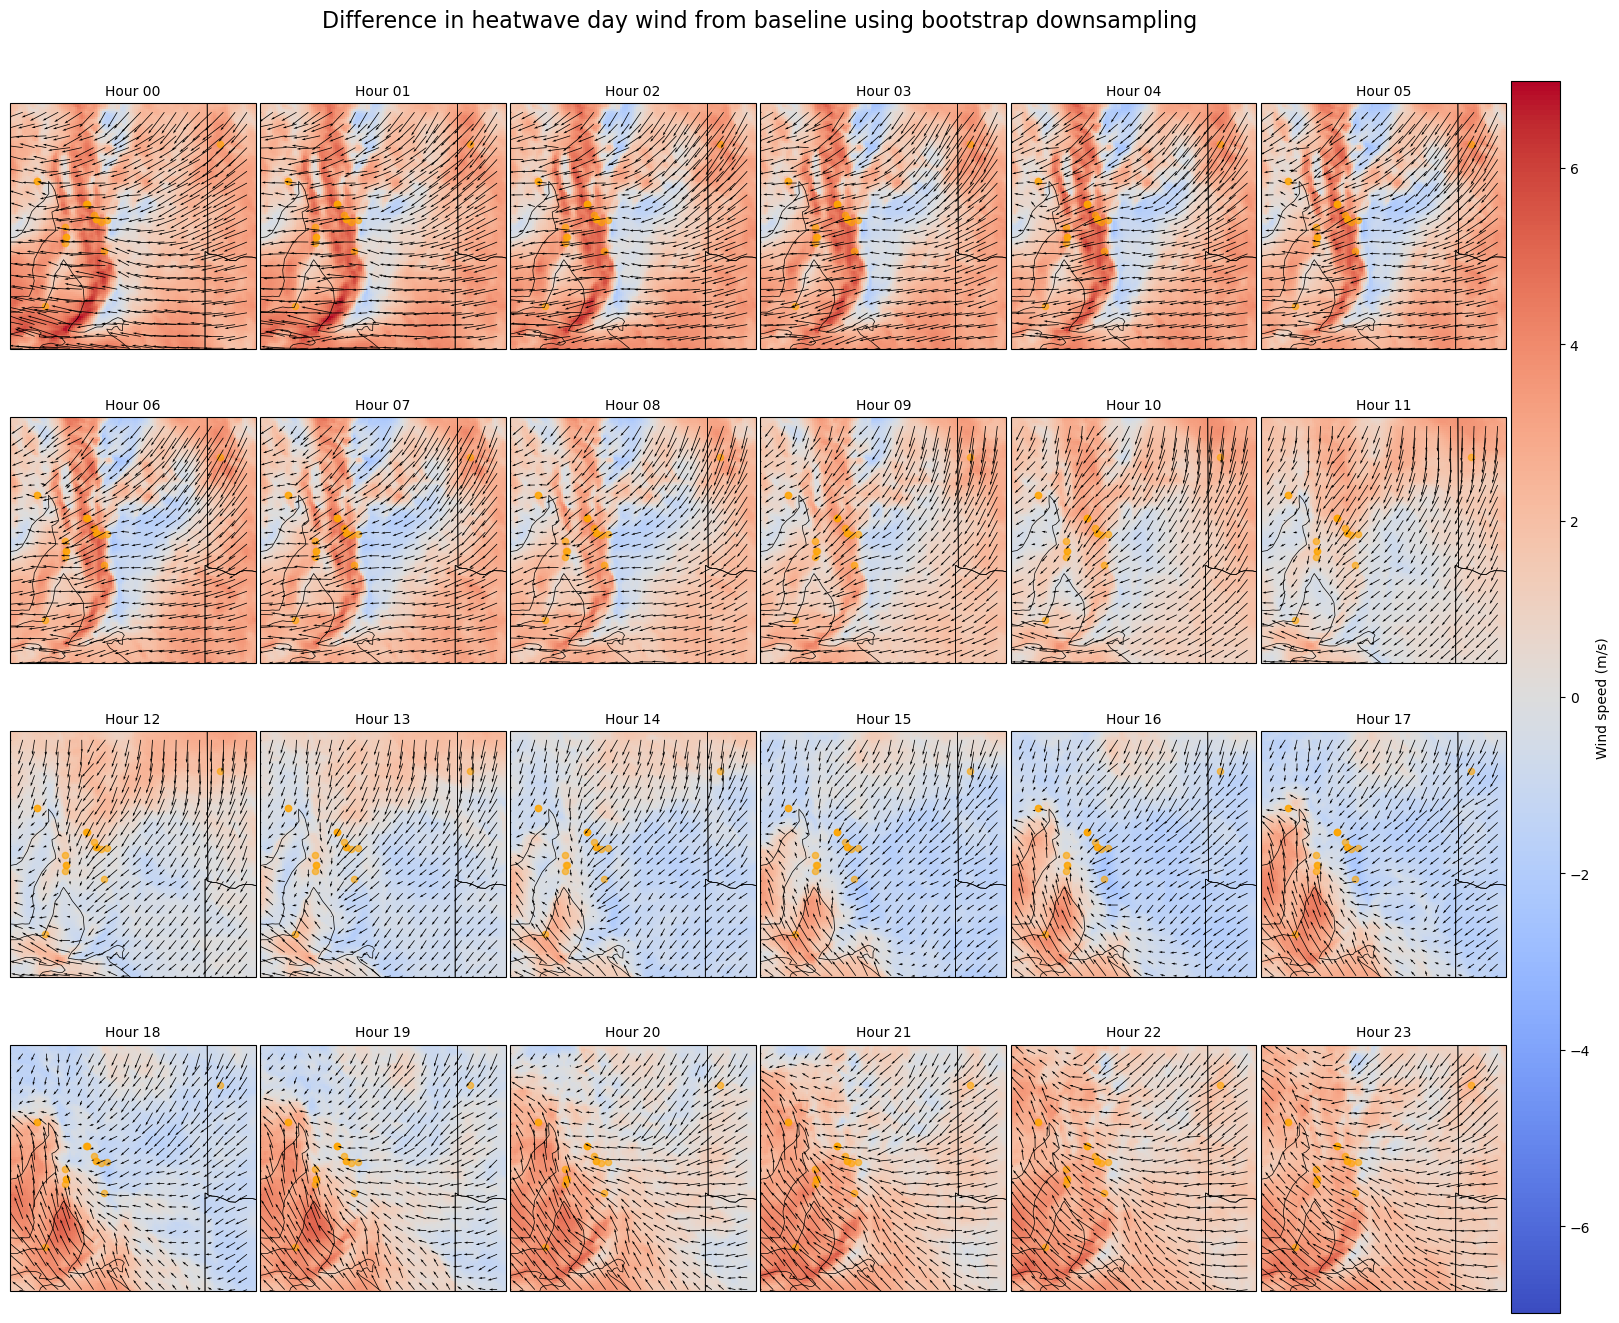

In [18]:
fig, axs = facet_plot_hours(
    lon=ds['lon'].values,
    lat=ds['lat'].values,
    scalar=ds['diff_speed_signed'].values,
    u=ds['diff_u_mean'].values,
    v=ds['diff_v_mean'].values,
    stipple=ds['diff_sig_joint_005'],
    hours=None,
    ncols=6,
    center_diff=True,
    figsize=(20, 16),
    cmap='coolwarm',
    quiver_color='black',
    colorbar_label='Wind speed (m/s)',
    title = "Difference in heatwave day wind from baseline using bootstrap downsampling"
    )
plt.savefig("/g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/bootstrap_diff_faceted.png")

In [19]:
liberal_joint_pval = xr.ufuncs.minimum(ds['diff_u_pval'], ds['diff_v_pval'])
liberal_joint_pval.min()

<xarray.DataArray ()> Size: 8B
array(0.44299999)
Coordinates:
    height   float64 8B 100.0
    crs      int32 4B 0

In [20]:
bl_var = ds['bl_speed_std']**2
hw_var = ds['hw_speed_std']**2
varmin = min(bl_var.min(),hw_var.min())
varmax = max(bl_var.max(),hw_var.max())

# fig, axs = facet_plot_hours(
#     lon=ds['lon'].values,
#     lat=ds['lat'].values,
#     scalar=bl_var.values,
#     hours=None,
#     ncols=6,
#     vmin=varmin,
#     vmax=varmax,
#     figsize=(20, 16),
#     cmap='viridis',
#     colorbar_label='Variance (m/s)^2',
#     title = "Variance of bootstrapped baseline composite"
#     )
# plt.savefig("/g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/no_hw/C2/bootstrap_var_bl.png")
# plt.show()

In [21]:
hw_var = ds['hw_speed_std']**2

# fig, axs = facet_plot_hours(
#     lon=ds['lon'].values,
#     lat=ds['lat'].values,
#     scalar=hw_var.values,
#     hours=None,
#     ncols=6,
#     vmin=varmin,
#     vmax=varmax,
#     figsize=(20, 16),
#     cmap='viridis',
#     colorbar_label='Variance (m/s)^2',
#     title = "Variance of bootstrapped heatwave composite"
#     )
# plt.savefig("/g/data/ng72/ms5578/ID_HW_BARRA/data/output/alpine_wind/hw/C2/bootstrap_var_hw.png")
# plt.show()

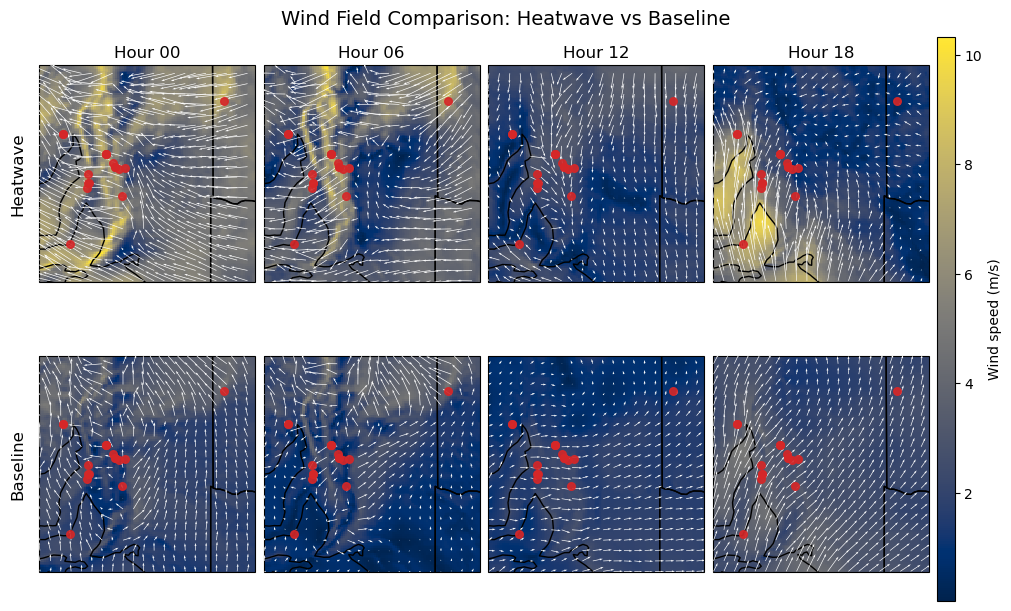

In [22]:
# Usage Example for Comparison Facet Plot
fig = compare_facet_hours(
    lon=ds['lon'].values,
    lat=ds['lat'].values,
    hw_scalar=ds['hw_speed_mean'].values,
    bl_scalar=ds['bl_speed_mean'].values,
    hw_u=ds['hw_u_mean'].values,
    hw_v=ds['hw_v_mean'].values,
    bl_u=ds['bl_u_mean'].values,
    bl_v=ds['bl_v_mean'].values,
    hours=[0, 6, 12, 18],  # Select your hours here
    figsize=(10, 6),
    cmap='cividis',
    colorbar_label='Wind speed (m/s)',
    title='Wind Field Comparison: Heatwave vs Baseline',
    highlight_id='WOODLWN1', highlight_green_ids=None
)
plt.show()


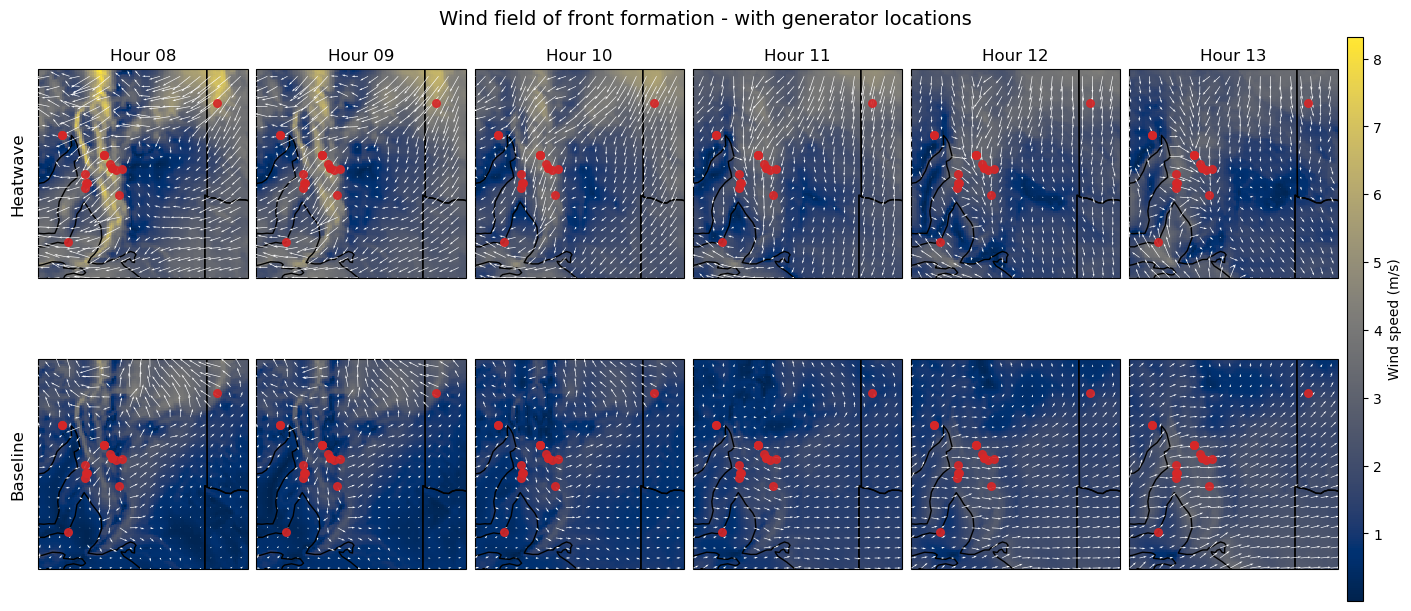

In [23]:
# Usage Example for Comparison Facet Plot
fig = compare_facet_hours(
    lon=ds['lon'].values,
    lat=ds['lat'].values,
    hw_scalar=ds['hw_speed_mean'].values,
    bl_scalar=ds['bl_speed_mean'].values,
    hours=[8,9,10,11,12,13],
    figsize=(14, 6),
    hw_u=ds['hw_u_mean'].values,
    hw_v=ds['hw_v_mean'].values,
    bl_u=ds['bl_u_mean'].values,
    bl_v=ds['bl_v_mean'].values,
    cmap='cividis',
    # cluster=None,
    colorbar_label='Wind speed (m/s)',
    title='Wind field of front formation - with generator locations',
    highlight_id='WOODLWN1', highlight_green_ids=None
)
plt.show()


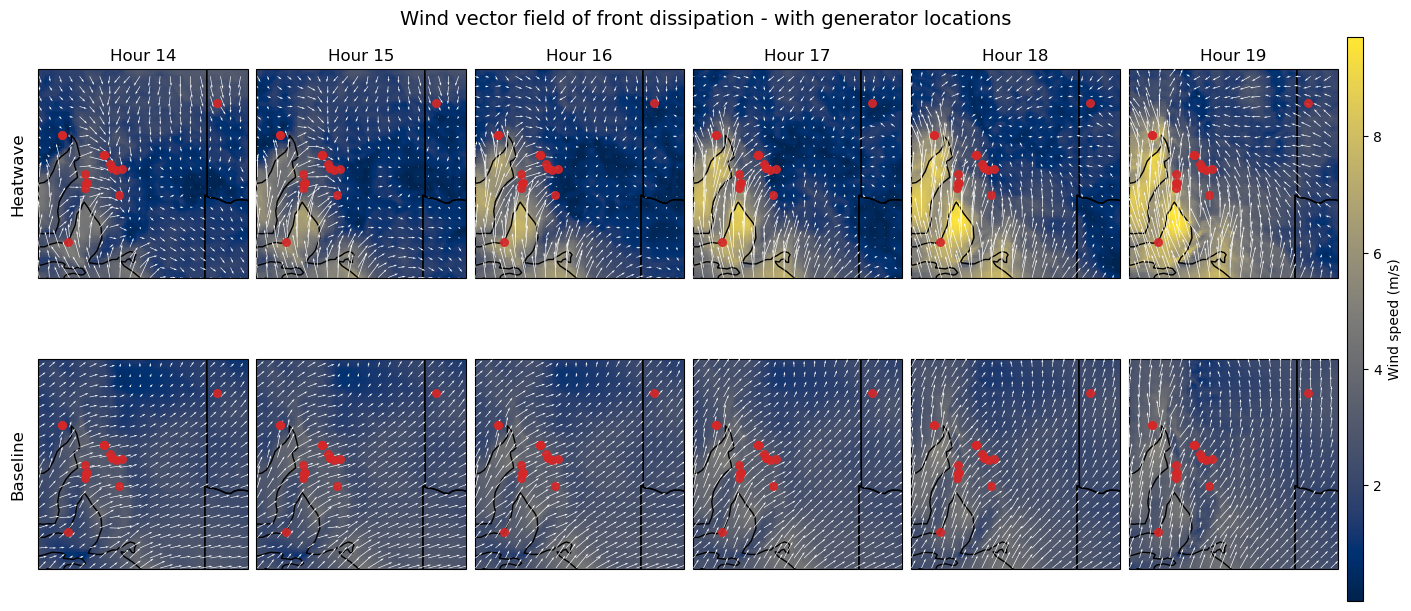

In [24]:
# Usage Example for Comparison Facet Plot
fig = compare_facet_hours(
    lon=ds['lon'].values,
    lat=ds['lat'].values,
    hw_scalar=ds['hw_speed_mean'].values,
    bl_scalar=ds['bl_speed_mean'].values,
    hw_u=ds['hw_u_mean'].values,
    hw_v=ds['hw_v_mean'].values,
    bl_u=ds['bl_u_mean'].values,
    bl_v=ds['bl_v_mean'].values,
    hours=[14,15,16,17,18,19],
    figsize=(14, 6),
    cmap='cividis',
    # cluster=None,
    colorbar_label='Wind speed (m/s)',
    title='Wind vector field of front dissipation - with generator locations',
    highlight_id='WOODLWN1', highlight_green_ids=None
)
plt.show()


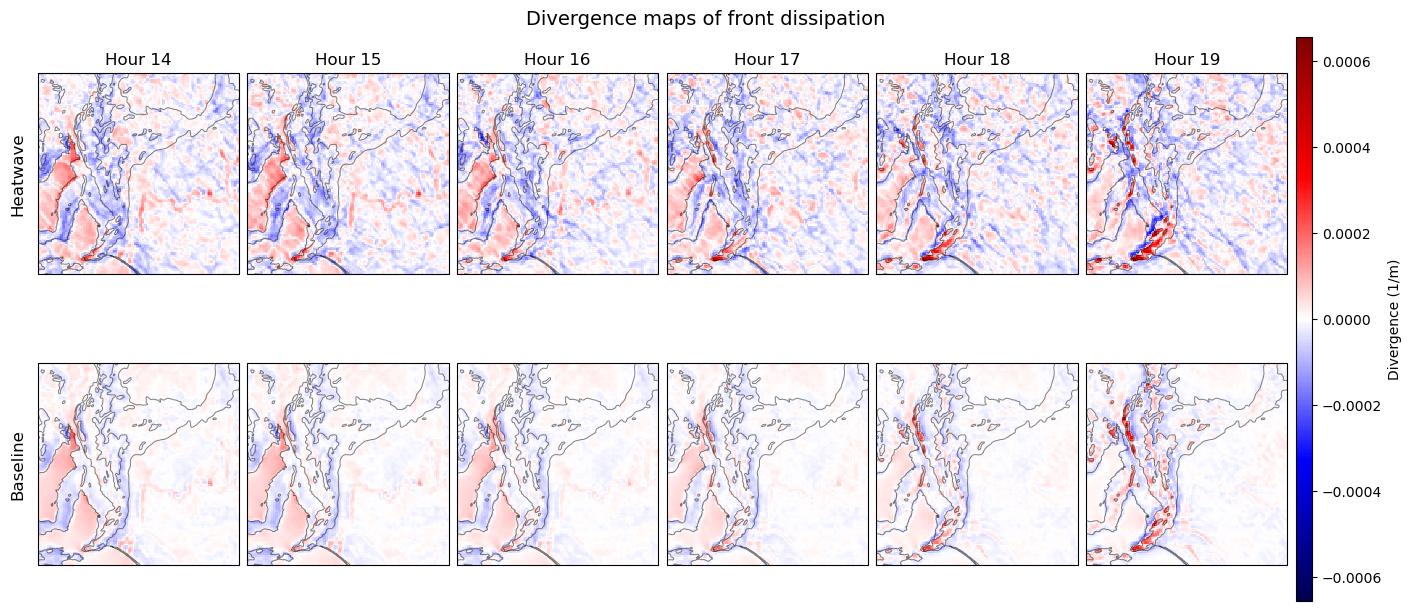

In [25]:
fig = compare_facet_divergence(
    lon=lon,
    lat=lat,
    hw_data=hw_div,  # From your existing calculation
    bl_data=bl_div,  # From your existing calculation
    hours=[14,15,16,17,18,19],
    figsize=(14, 6),
    cmap='seismic',
    cluster=None,
    title="Divergence maps of front dissipation"
)
plt.show()

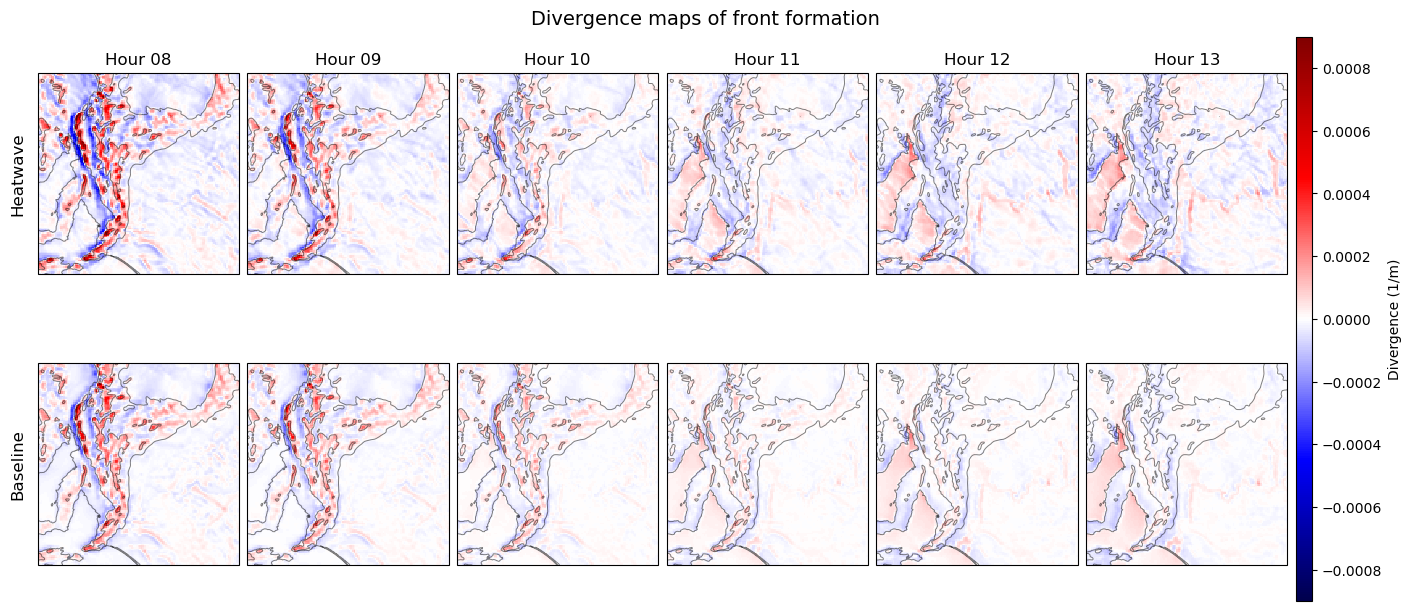

In [26]:
fig = compare_facet_divergence(
    lon=lon,
    lat=lat,
    hw_data=hw_div,  # From your existing calculation
    bl_data=bl_div,  # From your existing calculation
    hours=[8,9,10,11,12,13],
    figsize=(14, 6),
    cmap='seismic',
    cluster=None,
    title="Divergence maps of front formation"
)
plt.show()